# IMAGE REGISTRATION
The data I will use in this part of the project are T1_BRAIN, FMRI_SMOOTHED and the MNI SPACE, that are of different shape (first one is 3D, second one is 4D). So to perform a correct image registration from the FMRI img to the T1 img, first I need to exract a temporal slice of the fmri img transforming it in a 3D structure. Then the image registration between the T1 and the atlas will be trivial.

Some personal clarifications on the MNI space meaning:
MNI which stands for Montreal Neurological Institute, is a tridimensional reference system built by averaging many medical images, and it can be used as a standardized system to compare different subjects and use the same coordinates all around the world for a more efficient data sharing

In [16]:
# Standard imports
import os
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from pathlib import Path

import nibabel as nib
from nilearn import image

# Fsl commands imports
from fsl.wrappers import flirt, LOAD, applyxfm4D

from utils.display import *
from utils.filtering import fmriVolumesSmoothing
from utils.statistics import avgVolumeAlongTime
from utils.registration import *
from config import *

In [13]:
# Set FSL system paths

os.environ['FSLDIR'] = '/Users/tommasodelucchi/fsl'
os.environ["FSLOUTPUTTYPE"] = "NIFTI_GZ"
os.environ["PATH"] = (os.path.join(os.environ["FSLDIR"], "bin") + ":" + 
                      os.path.join(os.environ["FSLDIR"], "share", "fsl", "bin") + ":" + 
                      os.environ.get("PATH", ""))

In [14]:
t1_dict   = loadAndDisplay(T1_PATH, "T1-WEIGHTED", print_summary=False)
mask_dict = loadAndDisplay(MASK_PATH, 'MASK', print_summary=False)
fmri_dict = loadAndDisplay(FMRI_PATH, "FMRI", print_summary=False)
mni_dict  = loadAndDisplay(MNI_PATH, "MNI", print_summary=False)

bool_mask = mask_dict['data'].astype(bool)

# The two main data structures used for image registration
t1_brain = np.load('data/part1/t1_brain.npy')
fmri_smoothed = np.load('data/part1/fmri_smoothed.npy')

# To use flirt command we need .nii format data structures
t1_brain_nii      = image.new_img_like(t1_dict['img'],t1_brain)
fmri_smoothed_nii = image.new_img_like(fmri_dict['img'],fmri_smoothed)

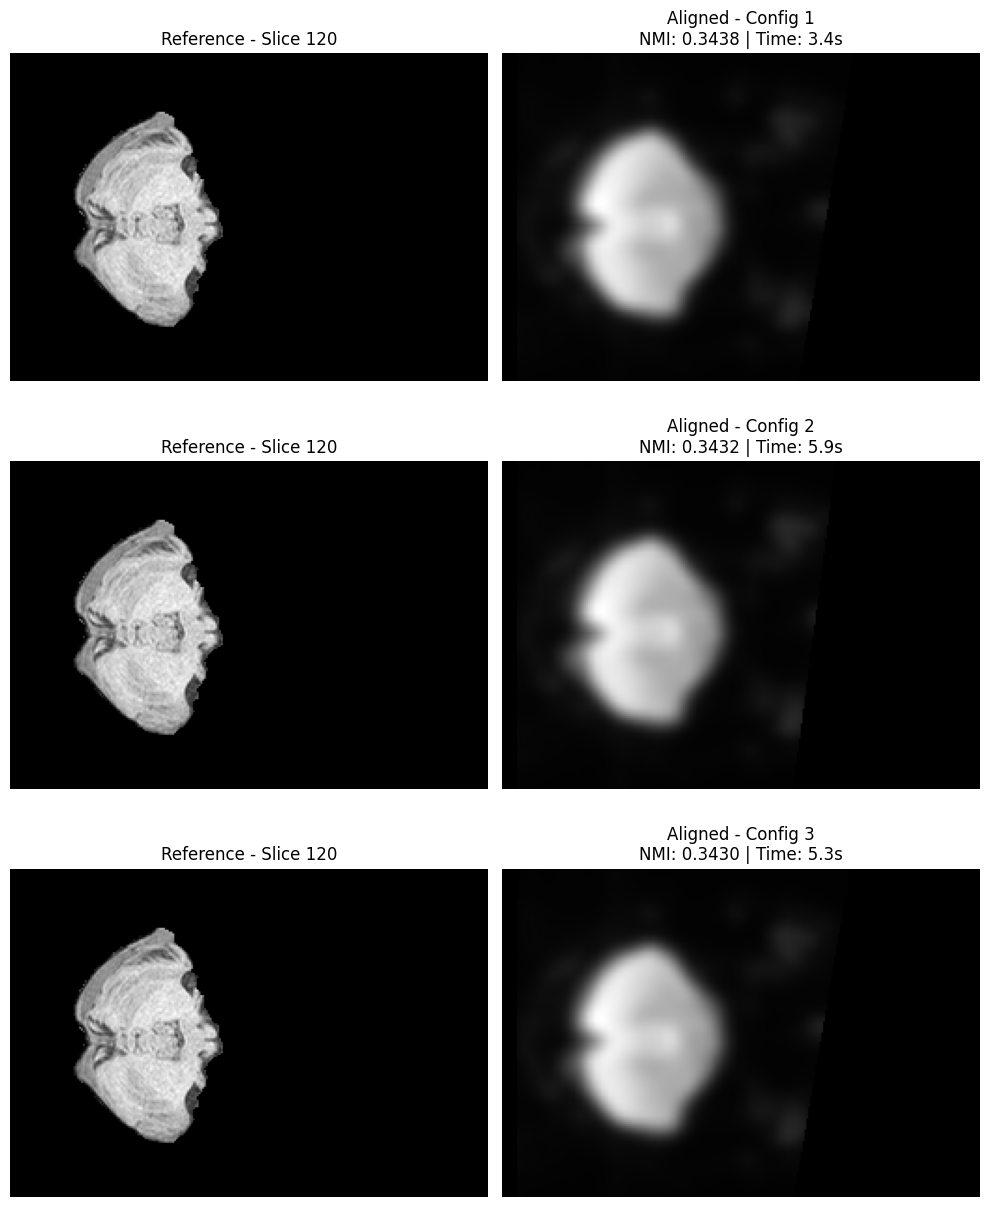

Matrice ottimale salvata in: data/part2/mat_fmri_to_t1.mat


In [4]:
from fsl.wrappers import bet, LOAD


# Registration from FMRI to T1-weighted image
ref = t1_brain_nii
avg_fmri_smoothed = avgVolumeAlongTime(fmri_smoothed)
src = image.new_img_like(fmri_dict['img'], avg_fmri_smoothed)

out_dir = Path("data/part2")
out_dir.mkdir(parents=True, exist_ok=True)

configs_fmri_t1 = [
    {'dof': 6, 'cost': 'corratio', 'interp': 'trilinear'},
    {'dof': 6, 'cost': 'mutualinfo', 'interp': 'trilinear'},
    {'dof': 6, 'cost': 'normmi', 'interp': 'trilinear'}
]

df_fmri_t1 = flirtRegistration(
    src=src,
    ref=ref,
    configs=configs_fmri_t1,
    slice_idx=120,
    axis=2,
    out_mat_path=out_dir / "mat_fmri_to_t1.mat"
)

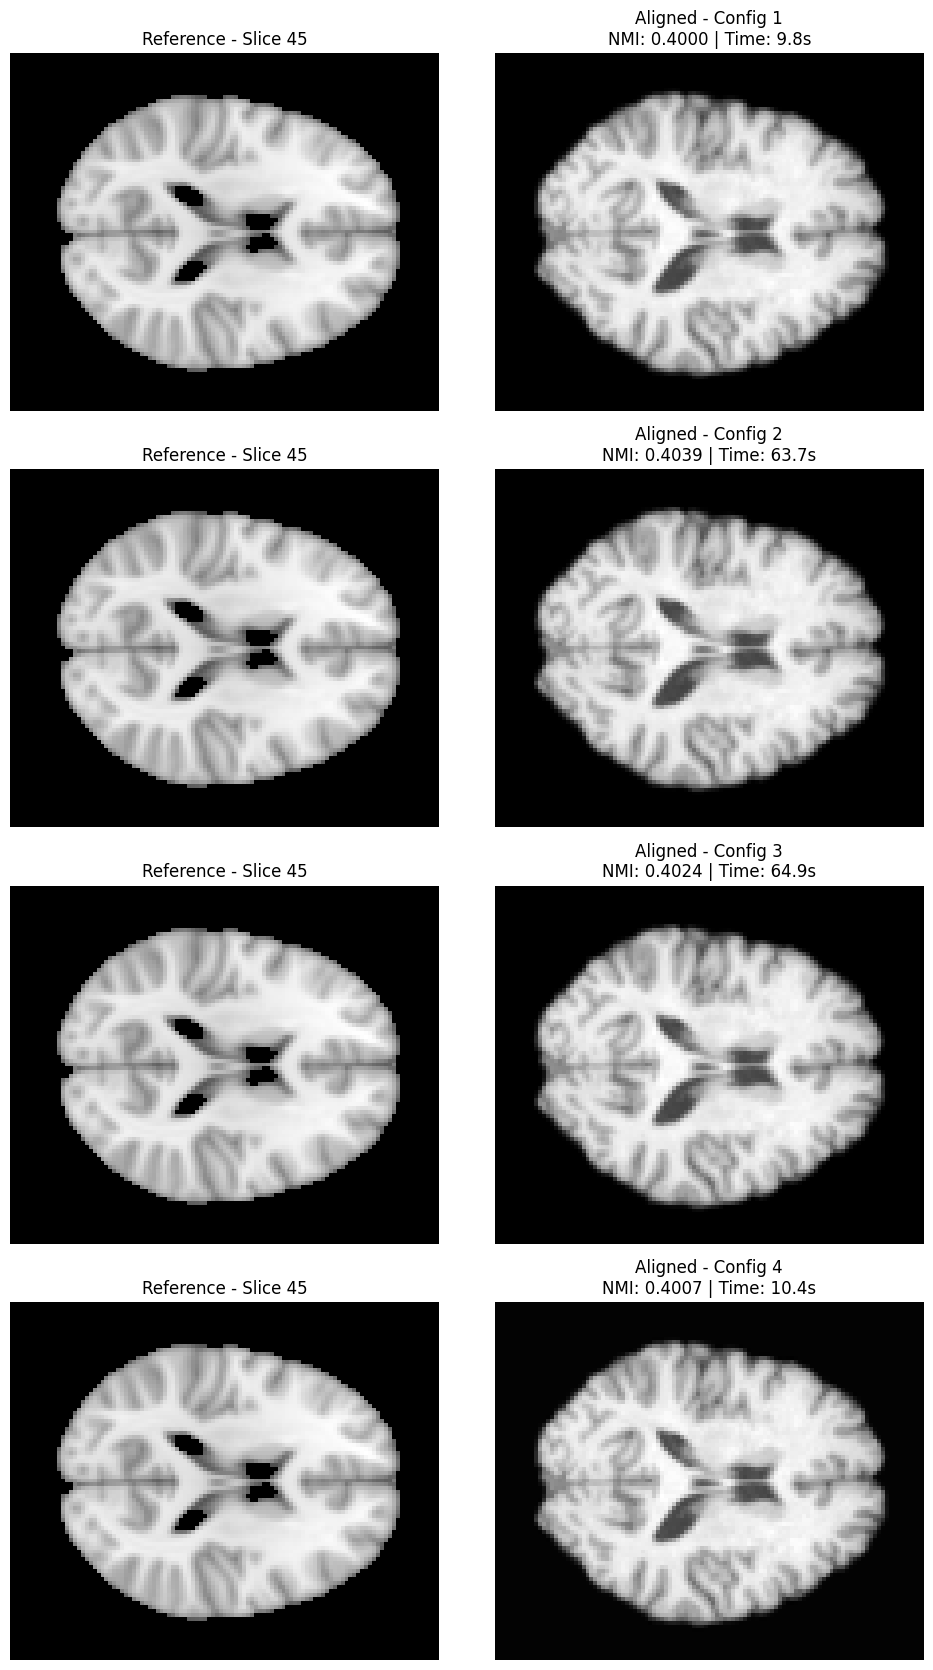

Matrice ottimale salvata in: data/part2/mat_t1_to_mni.mat


In [6]:
configs_t1_mni = [
    {'dof': 12, 'cost': 'corratio', 'interp': 'trilinear'},
    {'dof': 12, 'cost': 'mutualinfo', 'interp': 'trilinear'},
    {'dof': 12, 'cost': 'normmi', 'interp': 'trilinear'},
    {'dof': 12, 'cost': 'corratio', 'interp': 'spline'}
]

df_t1_mni = flirtRegistration(
    src=t1_brain_nii,
    ref=mni_dict['img'],
    configs=configs_t1_mni,
    slice_idx=45,
    axis=2,
    out_mat_path=out_dir / "mat_t1_to_mni.mat"
)

In [15]:
out_dir = Path("data/part2")
mat_fmri_to_t1 = out_dir / "mat_fmri_to_t1.mat"
mat_t1_to_mni  = out_dir / "mat_t1_to_mni.mat"
mat_final      = out_dir / "mat_fmri_to_mni.mat"
out_4d_mni     = out_dir / "fmri_in_MNI_4D.nii.gz"

from fsl.utils.run import run
run(f"convert_xfm -omat {mat_final} -concat {mat_t1_to_mni} {mat_fmri_to_t1}")

# Applicazione all'intero volume 4D dell'fMRI
applyxfm4D(
    src=fmri_smoothed_nii,
    ref=mni_dict['img'],
    out=str(out_4d_mni),
    mat=str(mat_final),
    singlematrix=True,
    interp='trilinear'
)

print(f"Pipeline completata. Dataset 4D normalizzato nello spazio MNI salvato in: {out_4d_mni}")

Pipeline completata. Dataset 4D normalizzato nello spazio MNI salvato in: data/part2/fmri_in_MNI_4D.nii.gz


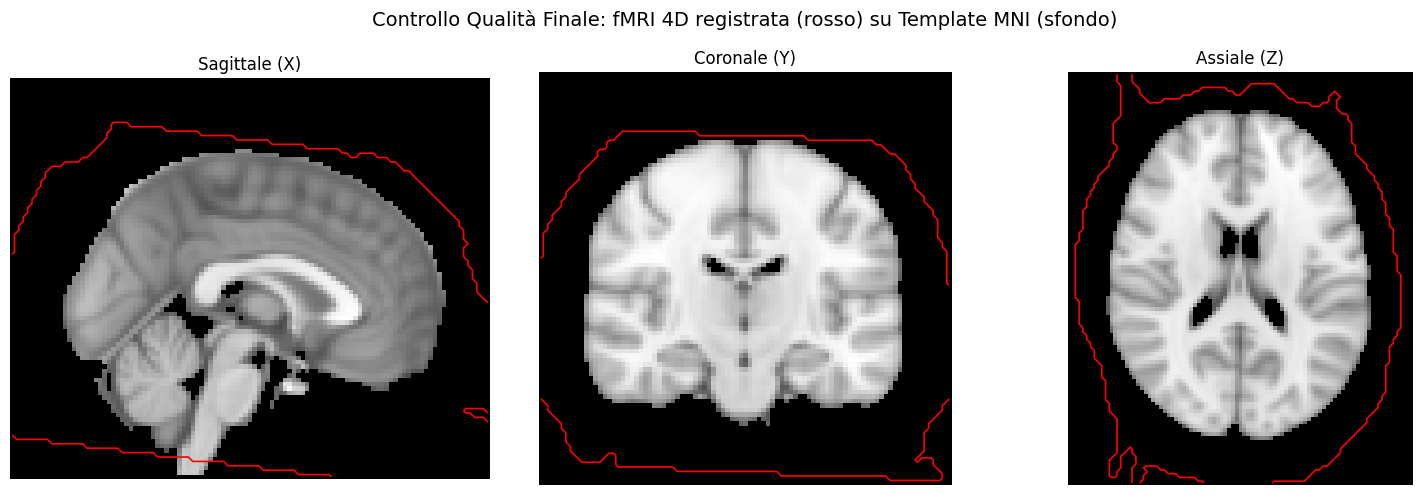

Shape finale 4D: (91, 109, 91, 200)
Risoluzione voxel (affine diagonal): [-2.  2.  2.]


In [17]:
# 1. Carica il volume 4D registrato e il template MNI
fmri_mni_img = nib.load(str(out_4d_mni))
fmri_mni_data = fmri_mni_img.get_fdata()

mni_data = mni_dict['img'].get_fdata() if hasattr(mni_dict['img'], 'get_fdata') else mni_dict['img'].data

# Fai una media temporale del 4D per la visualizzazione anatomica
fmri_mean_mni = np.mean(fmri_mni_data, axis=-1)

# 2. Definisci coordinate centrali nello spazio MNI 2mm (tipicamente 91 x 109 x 91)
x_mid, y_mid, z_mid = np.array(mni_data.shape) // 2

slices = [
    ("Sagittale (X)", mni_data[x_mid, :, :].T, fmri_mean_mni[x_mid, :, :].T),
    ("Coronale (Y)",  mni_data[:, y_mid, :].T, fmri_mean_mni[:, y_mid, :].T),
    ("Assiale (Z)",   mni_data[:, :, z_mid].T, fmri_mean_mni[:, :, z_mid].T)
]

# 3. Plot Ortogonale con Overlay
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (title, ref_slice, fmri_slice) in zip(axes, slices):
    # Sfondo: Template MNI
    ax.imshow(ref_slice, cmap='gray', origin='lower')
    
    # Contorno rosso: perimetro del cervello funzionale registrato
    thresh = np.percentile(fmri_slice[fmri_slice > 0], 25) if np.any(fmri_slice > 0) else 0
    ax.contour(fmri_slice > thresh, levels=[0.5], colors='red', linewidths=1.2)
    
    ax.set_title(title)
    ax.axis('off')

plt.suptitle("Controllo Qualità Finale: fMRI 4D registrata (rosso) su Template MNI (sfondo)", fontsize=14)
plt.tight_layout()
plt.show()

# 4. Verifica di consistenza sui dati
print(f"Shape finale 4D: {fmri_mni_data.shape}")
print(f"Risoluzione voxel (affine diagonal): {np.diag(fmri_mni_img.affine)[:3]}")